# bagelR sequential "daily" example

## Install bagelR

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/Rtmp3Waqlm/remotes45d4c7eb8aef0/grosed-bagel-e6163c3/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.7.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.7.0’

## Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




## Define the feature vector function 

In [4]:
feature_vector_daily <- function(t,tau)
{
  if(tau==0){
    M <- matrix(c(0),nc=1,nr=7)
    M[1,1] <- 1
    M[t%%7+1,1] <- 1
  }else{
    M <- matrix(c(0),nc=1,nr=8)
    M[1,1] <- 1
    M[t%%7+1,1] <- 1
    if(t>tau){
      M[8,1] <- 1
    }
  }
  return(M)
}



## Define the prior function

In [5]:
prior_daily <- function(t){
  if(t==1){
    mu <- matrix(rep(0,7),nc=1,nr=7)
    sigma <- diag(c(10,rep(1,6)))
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(rep(0,8),nc=1,nr=8)
  sigma <- diag(c(10,rep(1,7)))
  return(list("mu" = mu,"sigma" = sigma))
  }

## Define the transform function

In [6]:
transform_daily <- function(tau)
{
  return(matrix(c(1,0,0,0,0,0,0,1),1,8,byrow=TRUE))
}

## Generate the data

In [7]:
set.seed(1)

In [8]:
Y <- rnorm(1000,0,1)
for(j in 1:6){
  daily.effect <- rnorm(1)
  Y[j+7*(0:142)] <- Y[j+7*(0:142)] +daily.effect
}
Y[901:1000]<-Y[901:1000]+1

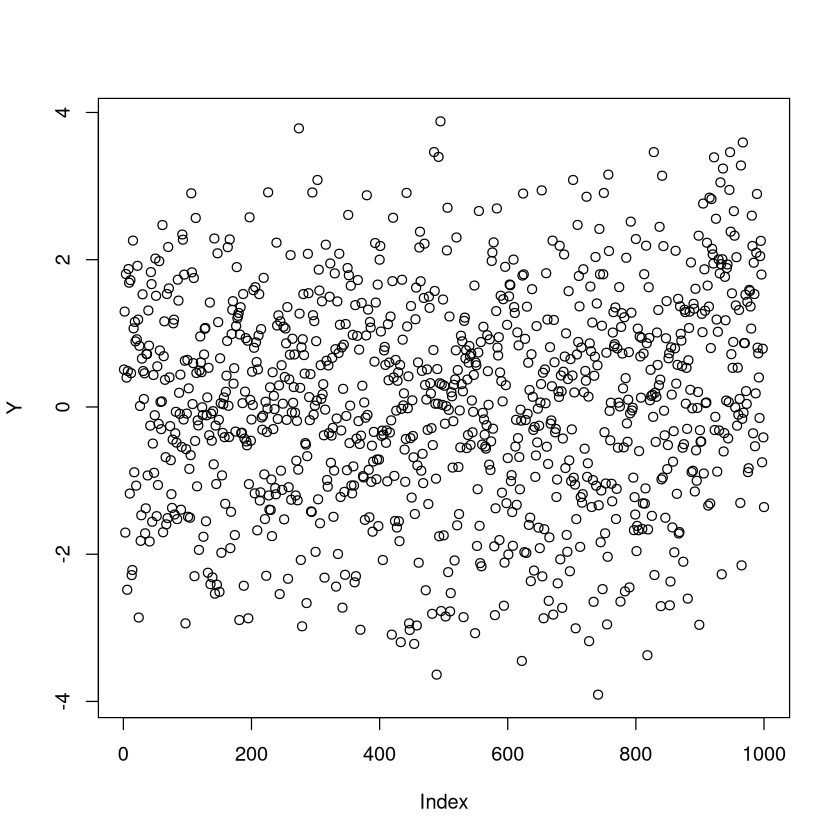

In [9]:
plot(Y)

## Set model parameters 

In [10]:
p <- 1.0;
p0 <- 0.9;
noise_nu <- 1.0;
noise_iota <- 1.0
max_particles <- 200
threshold <- 0.8

In [11]:
bagel_object <- sequential_bagel_uv_approximate(feature_vector_daily,
                                                prior_daily,
                                                transform_daily,
                                                p0,p,noise_nu,noise_iota,max_particles)

In [12]:
w0ts <- list()
min_active_weight_particle_attributes <- list()
for(y in Y[1:300])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   min_active_weight_index <- which.min(as.numeric(active_weights(bagel_object)))
   particle_attributes <- list("time" = time(bagel_object),
                               "tau" = taus(bagel_object)[[min_active_weight_index]],
                               "weight" = weights(bagel_object)[[min_active_weight_index]],
                               "mu" = mus(bagel_object)[[min_active_weight_index]],
                               "sigma" = sigmas(bagel_object)[[min_active_weight_index]],
                               "nu" = nu(bagel_object),
                               "iota" = iota(bagel_object))
   min_active_weight_particle_attributes <- append(min_active_weight_particle_attributes,list(particle_attributes))   
   if(1.0 - w0t > threshold)
    {

       print("changepoint !!")
	   break
    }
}

## Examine progress

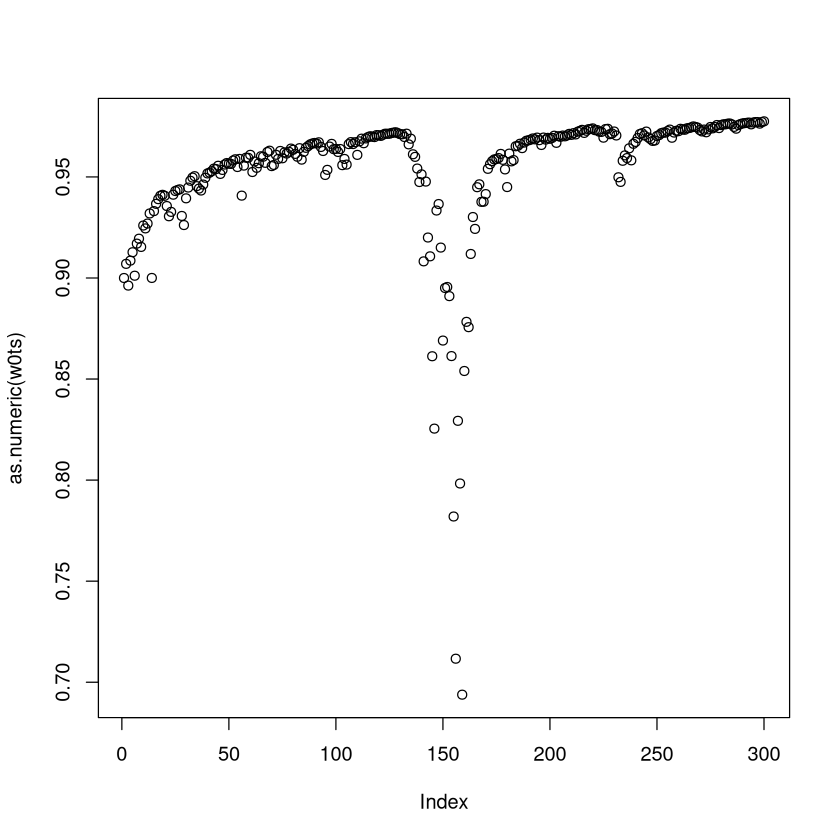

In [13]:
plot(as.numeric(w0ts))

In [14]:
min_active_weight_particle_attributes[length(min_active_weight_particle_attributes)]

[[1]]
[[1]]$time
[1] 300

[[1]]$tau
[1] 149

[[1]]$weight
[1] 5.813793e-05

[[1]]$mu
            [,1]
[1,] -0.05370266
[2,]  1.16101283
[3,]  1.08589327
[4,] -0.57392908
[5,]  0.15027911
[6,]  0.36413826
[7,] -1.57901059
[8,] -0.00161824

[[1]]$sigma
             [,1]          [,2]          [,3]         [,4]         [,5]
[1,]  0.024131518 -0.0204463169 -0.0204463169 -0.020296947 -0.020296947
[2,] -0.020446317  0.0426410196  0.0199137468  0.019910514  0.019910514
[3,] -0.020446317  0.0199137468  0.0426410196  0.019910514  0.019910514
[4,] -0.020296947  0.0199105144  0.0199105144  0.042641352  0.019914079
[5,] -0.020296947  0.0199105144  0.0199105144  0.019914079  0.042641352
[6,] -0.020296947  0.0199105144  0.0199105144  0.019914079  0.019914079
[7,] -0.020296947  0.0199105144  0.0199105144  0.019914079  0.019914079
[8,] -0.006572253  0.0001422269  0.0001422269 -0.000156852 -0.000156852
             [,6]         [,7]          [,8]
[1,] -0.020296947 -0.020296947 -0.0065722531
[2,]  0.019910514  0.019910514  0.0001422269
[3,]  0.019910514  0.019910514  0.0001422269
[4,]  0.019914079  0.019914079 -0.0001568520
[5,]  0.019914079  0.019914079 -0.0001568520
[6,]  0.042641352  0.019914079 -0.0001568520
[7,]  0.019914079  0.042641352 -0.0001568520
[8,] -0.000156852 -0.000156852  0.0131594715

[[1]]$nu
[1] 151

[[1]]$iota
[1] 139.9411

## Restart the analysis

In [15]:
for(y in Y[301:1000])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   min_active_weight_index <- which.min(as.numeric(active_weights(bagel_object)))
   particle_attributes <- list("time" = time(bagel_object),
                               "tau" = taus(bagel_object)[[min_active_weight_index]],
                               "weight" = weights(bagel_object)[[min_active_weight_index]],
                               "mu" = mus(bagel_object)[[min_active_weight_index]],
                               "sigma" = sigmas(bagel_object)[[min_active_weight_index]],
                               "nu" = nu(bagel_object),
                               "iota" = iota(bagel_object))
   min_active_weight_particle_attributes <- append(min_active_weight_particle_attributes,list(particle_attributes))   
   if(1.0 - w0t > threshold)
    {

       print("changepoint !!")
	   break
    } 
}

[1] "changepoint !!"


## Examine progress

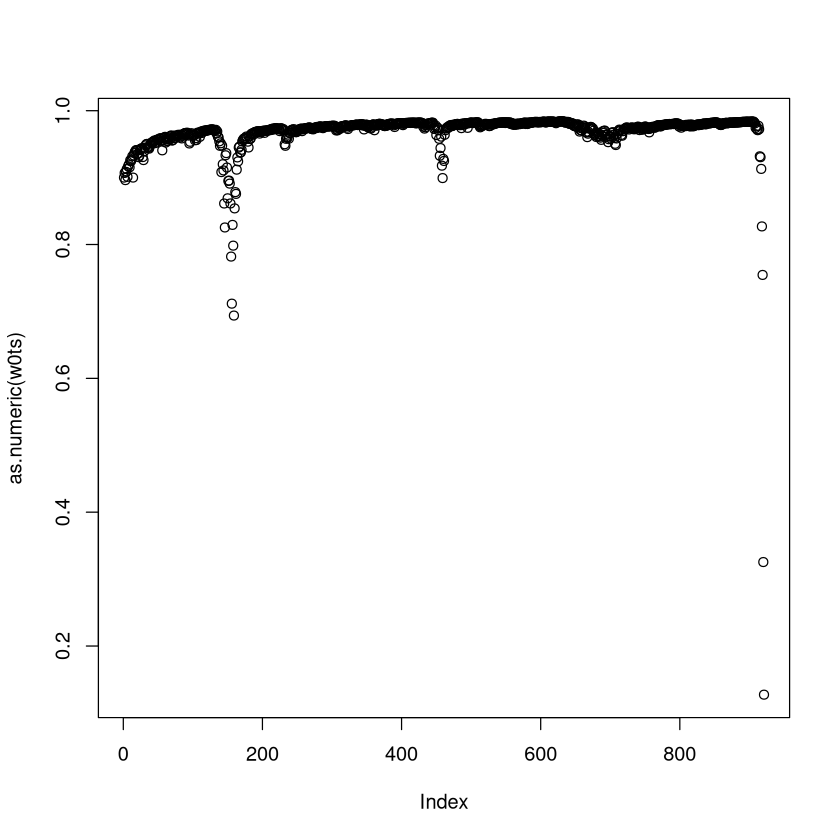

In [16]:
plot(as.numeric(w0ts))

In [17]:
min_active_weight_particle_attributes[length(min_active_weight_particle_attributes)]

[[1]]
[[1]]$time
[1] 921

[[1]]$tau
[1] 583

[[1]]$weight
[1] 2.983145e-06

[[1]]$mu
             [,1]
[1,] -0.050281211
[2,]  1.229484068
[3,]  1.136020343
[4,] -0.618616520
[5,]  0.182240683
[6,]  0.232405268
[7,] -1.738867776
[8,] -0.001633195

[[1]]$sigma
             [,1]          [,2]          [,3]          [,4]          [,5]
[1,]  0.007920107 -7.245784e-03 -7.245784e-03 -7.232976e-03 -7.232976e-03
[2,] -0.007245784  1.470587e-02  7.187075e-03  7.186987e-03  7.186987e-03
[3,] -0.007245784  7.187075e-03  1.470587e-02  7.186987e-03  7.186987e-03
[4,] -0.007232976  7.186987e-03  7.186987e-03  1.470596e-02  7.187162e-03
[5,] -0.007232976  7.186987e-03  7.186987e-03  7.187162e-03  1.470596e-02
[6,] -0.007240675  7.186631e-03  7.186631e-03  7.186639e-03  7.186639e-03
[7,] -0.007240675  7.186631e-03  7.186631e-03  7.186639e-03  7.186639e-03
[8,] -0.001703435  1.171711e-05  1.171711e-05 -2.326018e-05 -2.326018e-05
              [,6]          [,7]          [,8]
[1,] -7.240675e-03 -7.240675e-03 -1.703435e-03
[2,]  7.186631e-03  7.186631e-03  1.171711e-05
[3,]  7.186631e-03  7.186631e-03  1.171711e-05
[4,]  7.186639e-03  7.186639e-03 -2.326018e-05
[5,]  7.186639e-03  7.186639e-03 -2.326018e-05
[6,]  1.476198e-02  7.186221e-03 -1.098935e-06
[7,]  7.186221e-03  1.476198e-02 -1.098935e-06
[8,] -1.098935e-06 -1.098935e-06  4.651980e-03

[[1]]$nu
[1] 461.5

[[1]]$iota
[1] 498.8604

## Changepoint information

#### detected

In [18]:
time(bagel_object)

[1] 921

#### location

In [19]:
which.max(weights(bagel_object))

[1] 902

## Examine particle 0

In [20]:
min_active_weight_particle_attributes[1]

[[1]]
[[1]]$time
[1] 1

[[1]]$tau
[1] 0

[[1]]$weight
[1] 0.9

[[1]]$mu
           [,1]
[1,] 0.42375940
[2,] 0.04237594
[3,] 0.00000000
[4,] 0.00000000
[5,] 0.00000000
[6,] 0.00000000
[7,] 0.00000000

[[1]]$sigma
           [,1]       [,2] [,3] [,4] [,5] [,6] [,7]
[1,]  1.6666667 -0.8333333    0    0    0    0    0
[2,] -0.8333333  0.9166667    0    0    0    0    0
[3,]  0.0000000  0.0000000    1    0    0    0    0
[4,]  0.0000000  0.0000000    0    1    0    0    0
[5,]  0.0000000  0.0000000    0    0    1    0    0
[6,]  0.0000000  0.0000000    0    0    0    1    0
[7,]  0.0000000  0.0000000    0    0    0    0    1

[[1]]$nu
[1] 1.5

[[1]]$iota
[1] 1.010774